# Next-Day Fatigue Score Prediction Using Support Vector Regression

This notebook presents a complete machine learning pipeline for predicting the **next-day fatigue score** — a continuous value ranging from 1.0 to 10.0 — based on behavioral and physiological features extracted from bedtime phone usage and sleep quality records.

The dataset, `bedtime_screentime_sleep_debt.csv`, captures 8,500 individuals' digital habits before sleep, sleep architecture metrics, and the resulting fatigue experienced the following day.

The chosen algorithm is **Support Vector Regression (SVR)** with an RBF kernel, selected for its robustness with moderate-sized datasets, strong generalization capability through the margin-based optimization framework, and its effectiveness in non-linear regression tasks where relationships between variables are complex and non-trivial.

---
## 1. Library Import and Environment Configuration

In [1]:
import subprocess
import sys

required = ["scikit-learn", "pandas", "numpy", "matplotlib", "seaborn", "joblib", "shap", "optuna"]
for pkg in required:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

In [2]:
import warnings
import os
import json
import joblib
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
ARTIFACT_DIR = os.path.join("model_artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

print(f"Artifact directory ready: {os.path.abspath(ARTIFACT_DIR)}")

Artifact directory ready: c:\Users\admin\Documents\Portofolio\Late Night Phone Habits\Model\model_artifacts


---
## 2. Data Loading and Initial Inspection

The dataset is loaded and subject to an initial structural and statistical inspection. The goal at this stage is to understand the shape of the data, identify column types, detect potential quality issues, and form a preliminary understanding of the distribution of the target variable.

In [3]:
DATA_PATH = os.path.join("..", "Dataset", "bedtime_screentime_sleep_debt.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8500, 18)


,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   str    
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   str    
 3   occupation_type           8500 non-null   str    
 4   chronotype                8500 non-null   str    
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   primary_bedtime_app       8500 non-null   str    
 7   screen_brightness_pct     8500 non-null   int64  
 8   blue_light_filter_active  8500 non-null   int64  
 9   caffeine_post_5pm_mg      8500 non-null   int64  
 10  physical_activity_min     8500 non-null   int64  
 11  sleep_latency_min         8500 non-null   float64
 12  total_sleep_hours         8500 non-null   float64
 13  deep_sleep_pct            8500 non-null   float64
 14  rem_sleep_pct      

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,8500,8500,USR-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,8500.0,NaN,NaN,NaN,34.355647,11.584259,18.0,25.0,32.0,42.0,65.0
gender,8500,3,Female,4347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation_type,8500,5,Corporate 9-to-5,2838,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronotype,8500,3,Intermediate,3880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedtime_phone_minutes,8500.0,NaN,NaN,NaN,59.25,36.931991,1.0,31.0,51.0,79.0,180.0
primary_bedtime_app,8500,6,TikTok / Reels,2198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_brightness_pct,8500.0,NaN,NaN,NaN,55.153882,19.85055,10.0,42.0,55.0,69.0,100.0
blue_light_filter_active,8500.0,NaN,NaN,NaN,0.467765,0.498989,0.0,0.0,0.0,1.0,1.0
caffeine_post_5pm_mg,8500.0,NaN,NaN,NaN,33.222471,51.935645,0.0,0.0,0.0,55.0,250.0


---
## 3. Data Cleaning

This section addresses data quality concerns including duplicate records, missing values, and potential outliers. The integrity of the input data directly affects the generalizability of the trained model.

### 3.1 Duplicate and Missing Value Assessment

In [6]:
print(f"Duplicate rows   : {df.duplicated().sum()}")
print(f"Missing values   :\n{df.isnull().sum()}")

Duplicate rows   : 0
Missing values   :
user_id                     0
age                         0
gender                      0
occupation_type             0
chronotype                  0
bedtime_phone_minutes       0
primary_bedtime_app         0
screen_brightness_pct       0
blue_light_filter_active    0
caffeine_post_5pm_mg        0
physical_activity_min       0
sleep_latency_min           0
total_sleep_hours           0
deep_sleep_pct              0
rem_sleep_pct               0
morning_alarm_snoozes       0
next_day_fatigue_score      0
sleep_debt_category         0
dtype: int64


In [7]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

df.drop(columns=["user_id"], inplace=True)

print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (8500, 17)


### 3.2 Outlier Detection Using the IQR Method

Outliers in numerical features are identified using the Interquartile Range (IQR) method. Records that fall beyond 3x the IQR boundary are considered extreme outliers and are removed to prevent them from distorting the SVR's margin-fitting process.

In [8]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

outlier_mask = pd.Series([False] * len(df))
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask |= (df[col] < Q1 - 3 * IQR) | (df[col] > Q3 + 3 * IQR)

print(f"Outlier rows identified : {outlier_mask.sum()}")
df = df[~outlier_mask].reset_index(drop=True)
print(f"Shape after outlier removal: {df.shape}")

Outlier rows identified : 89
Shape after outlier removal: (8411, 17)


---
## 4. Exploratory Data Analysis (EDA)

The EDA section provides visual insight into the statistical properties of the dataset, the distribution of the target variable, and the pairwise relationships between predictors and the outcome. This informs feature selection and preprocessing decisions.

### 4.1 Target Variable Distribution

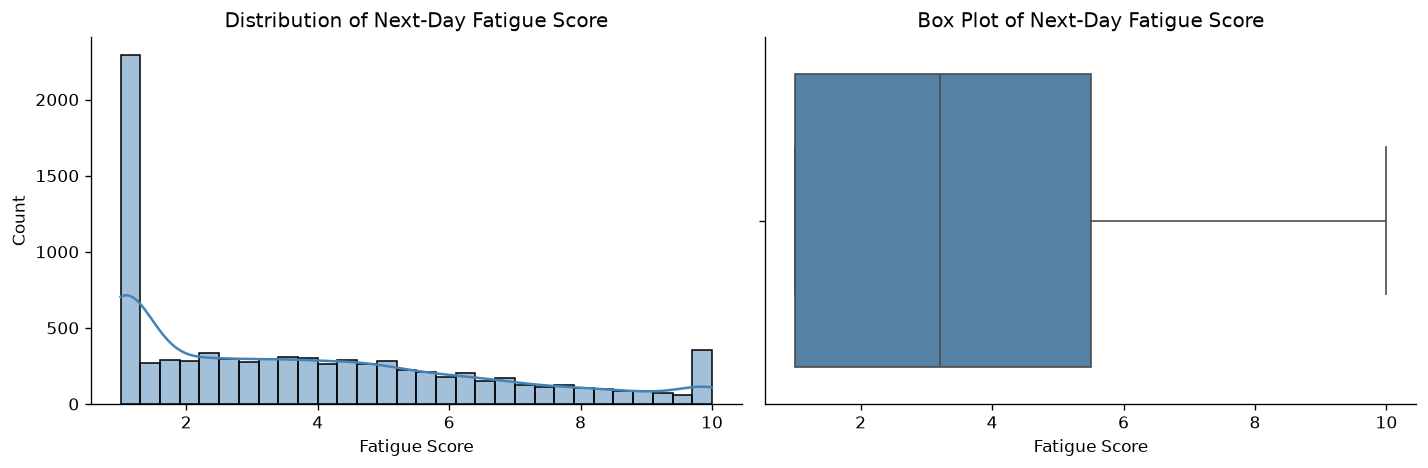

In [9]:
TARGET = "next_day_fatigue_score"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[TARGET], bins=30, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Next-Day Fatigue Score")
axes[0].set_xlabel("Fatigue Score")
axes[0].set_ylabel("Count")

sns.boxplot(x=df[TARGET], color="steelblue", ax=axes[1])
axes[1].set_title("Box Plot of Next-Day Fatigue Score")
axes[1].set_xlabel("Fatigue Score")

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "target_distribution.png"), bbox_inches="tight")
plt.show()

### 4.2 Correlation Heatmap (Numerical Features)

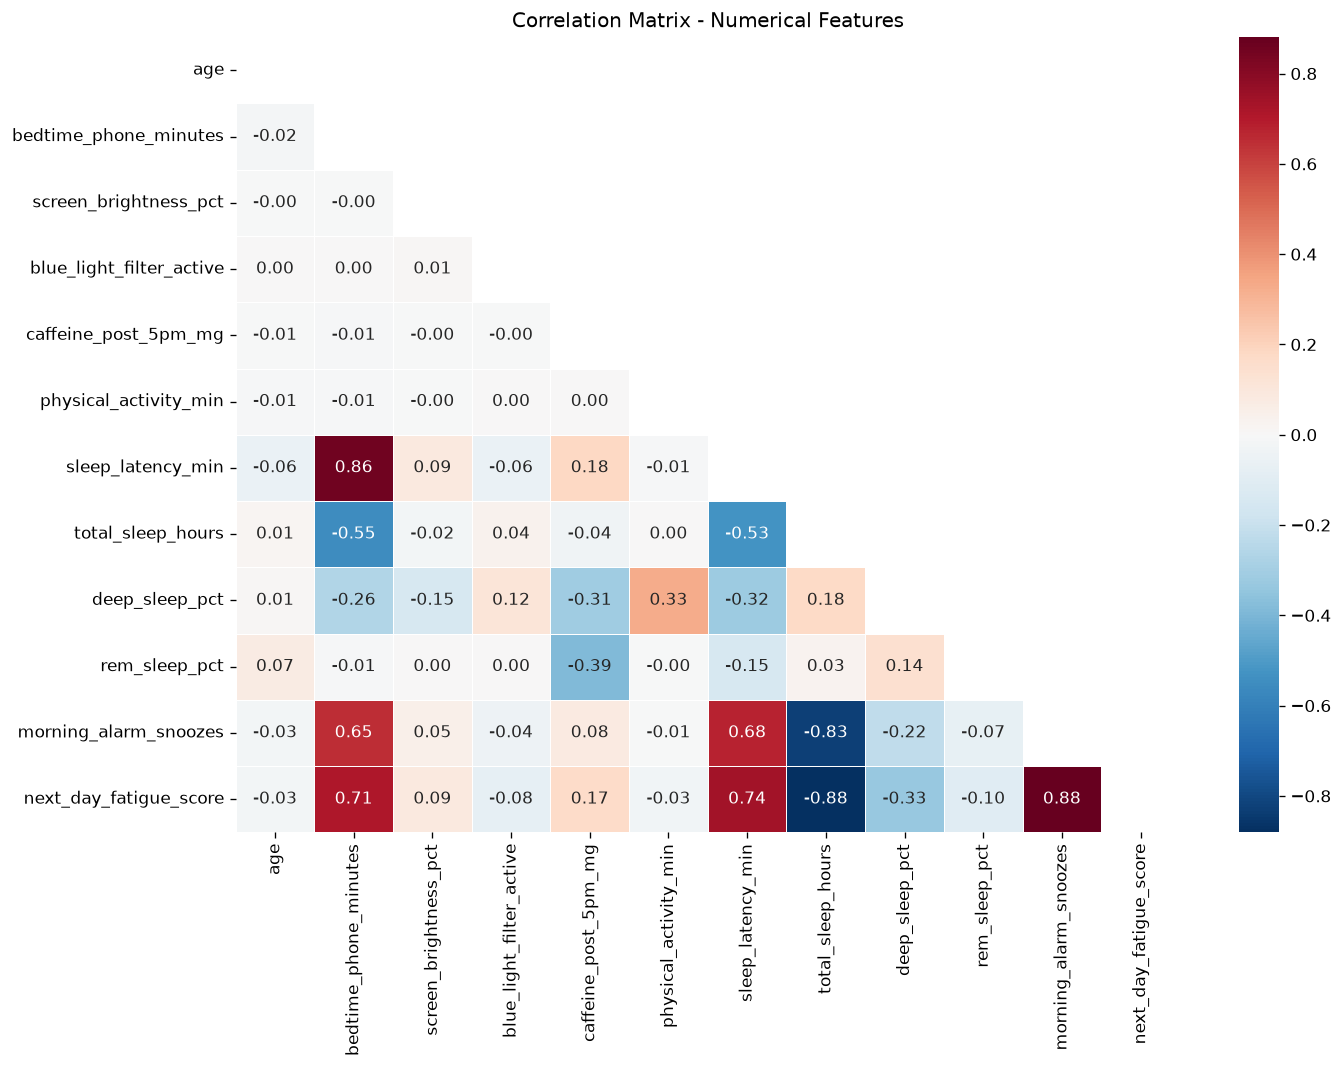

In [10]:
corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, linewidths=0.5, ax=ax
)
ax.set_title("Correlation Matrix - Numerical Features")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "correlation_heatmap.png"), bbox_inches="tight")
plt.show()

### 4.3 Feature Relationships with the Target Variable

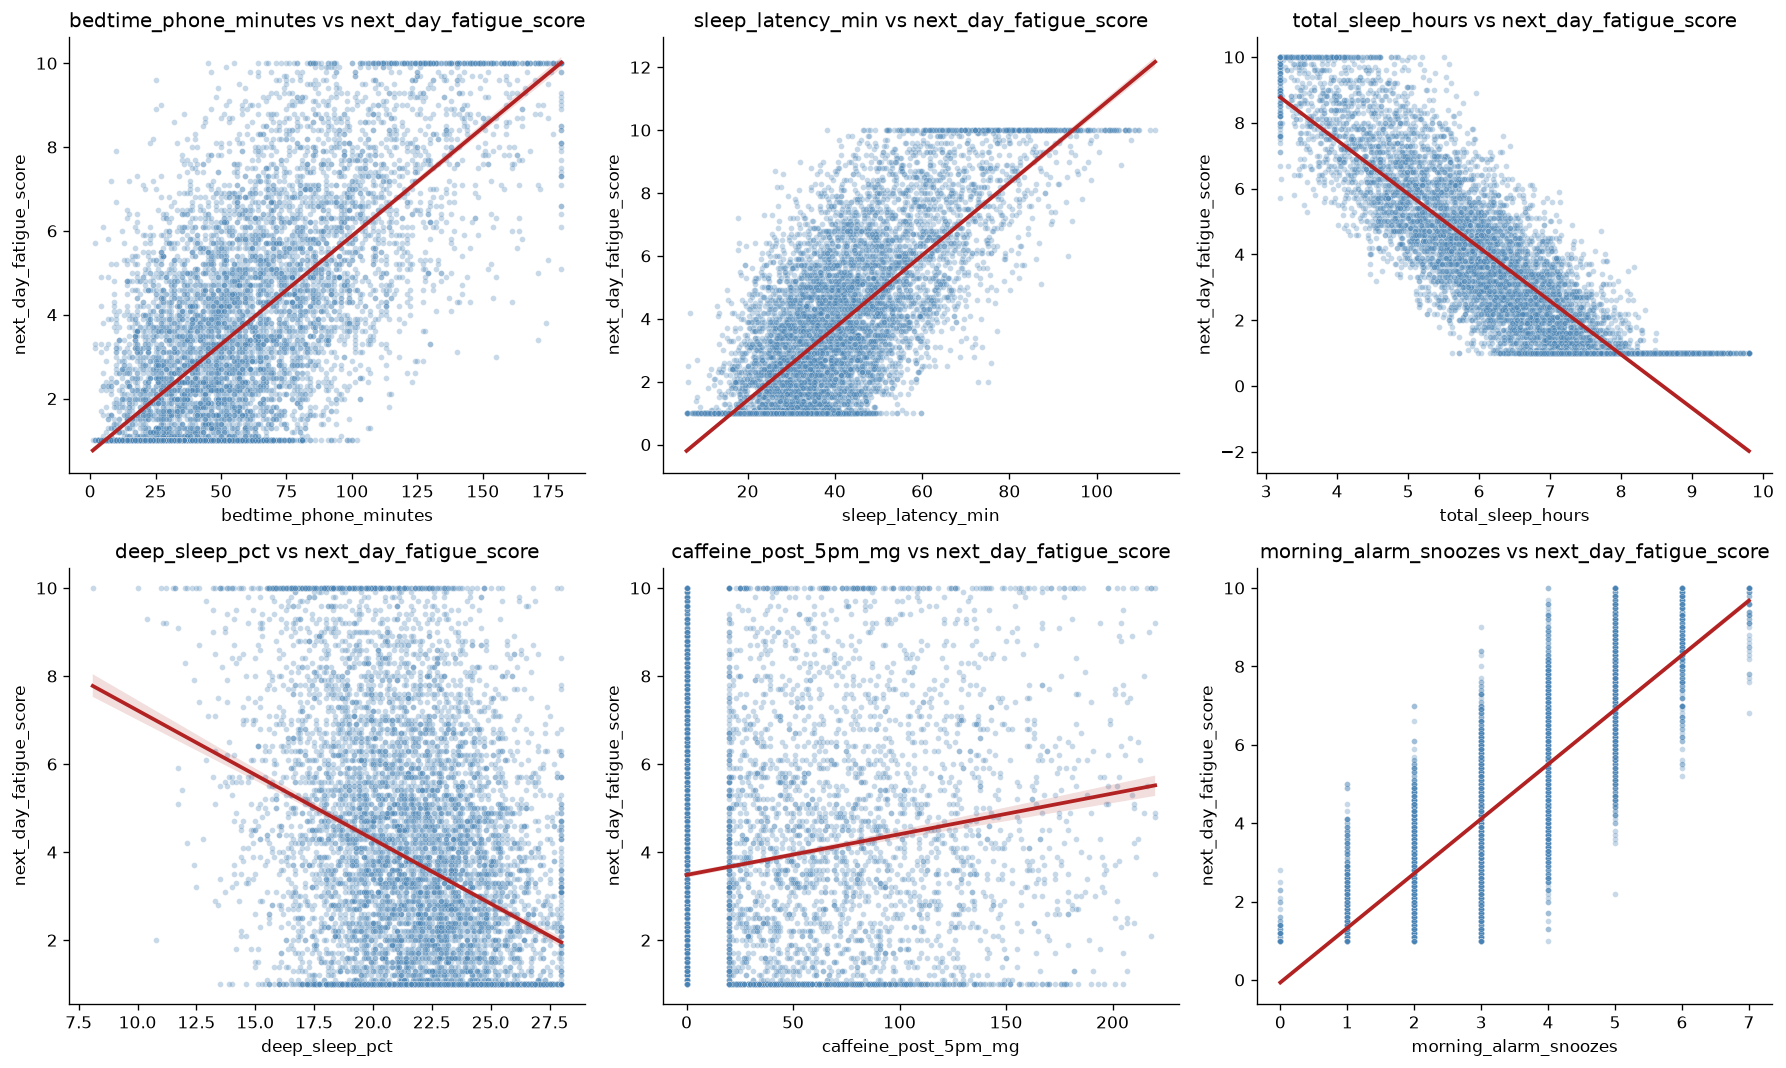

In [11]:
key_numeric = ["bedtime_phone_minutes", "sleep_latency_min", "total_sleep_hours",
               "deep_sleep_pct", "caffeine_post_5pm_mg", "morning_alarm_snoozes"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    sns.scatterplot(data=df, x=col, y=TARGET, alpha=0.3, s=12, color="steelblue", ax=axes[i])
    sns.regplot(data=df, x=col, y=TARGET, scatter=False, color="firebrick", ax=axes[i])
    axes[i].set_title(f"{col} vs {TARGET}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "scatter_feature_vs_target.png"), bbox_inches="tight")
plt.show()

### 4.4 Categorical Feature Analysis

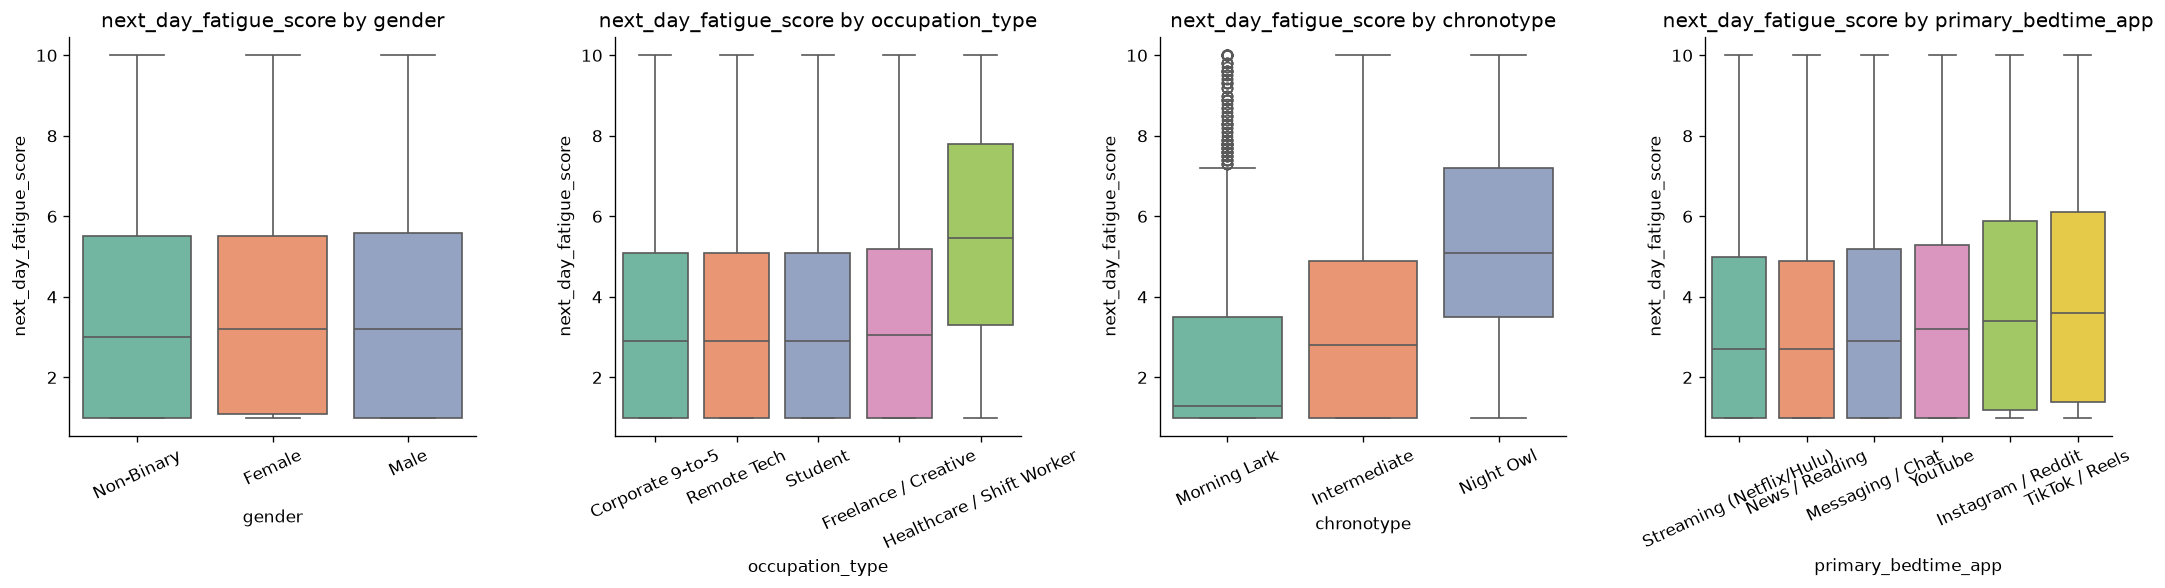

In [12]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols_to_plot = [c for c in cat_cols if c != "sleep_debt_category"]

fig, axes = plt.subplots(1, len(cat_cols_to_plot), figsize=(18, 5))
if len(cat_cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols_to_plot):
    order = df.groupby(col)[TARGET].median().sort_values().index
    sns.boxplot(data=df, x=col, y=TARGET, order=order, palette="Set2", ax=ax)
    ax.set_title(f"{TARGET} by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "categorical_vs_target.png"), bbox_inches="tight")
plt.show()

---
## 5. Feature Engineering and Preprocessing

This section defines the feature set used to train the SVR model and constructs the preprocessing pipeline. SVR is sensitive to feature scale, making standardization a mandatory preprocessing step for all numerical inputs.

### 5.1 Feature and Target Definition

In [13]:
DROP_FROM_FEATURES = [TARGET, "sleep_debt_category"]

X = df.drop(columns=DROP_FROM_FEATURES)
y = df[TARGET]

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Features used        : {X.columns.tolist()}")

Feature matrix shape : (8411, 15)
Target vector shape  : (8411,)
Features used        : ['age', 'gender', 'occupation_type', 'chronotype', 'bedtime_phone_minutes', 'primary_bedtime_app', 'screen_brightness_pct', 'blue_light_filter_active', 'caffeine_post_5pm_mg', 'physical_activity_min', 'sleep_latency_min', 'total_sleep_hours', 'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes']


### 5.2 Train-Test Split

The dataset is partitioned into a training set (80%) and a held-out test set (20%). The test set is reserved exclusively for final model evaluation and is not used during hyperparameter optimization.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 6728
Test samples     : 1683


### 5.3 Preprocessing Pipeline Construction

A `ColumnTransformer` is used to apply differentiated preprocessing to each feature type:

- **Numerical features**: `StandardScaler` normalizes values to zero mean and unit variance, which is critical for the SVR kernel's distance computations.
- **Ordinal categorical features**: `OrdinalEncoder` encodes categories with a defined order (e.g., `chronotype`: Morning Lark < Intermediate < Night Owl).
- **Nominal categorical features**: `OrdinalEncoder` with a learned mapping is applied. One-hot encoding is deliberately avoided to limit dimensionality for SVR.

In [15]:
NUMERIC_FEATURES = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

CHRONOTYPE_ORDER = [["Morning Lark", "Intermediate", "Night Owl"]]
ORDINAL_FEATURES = ["chronotype"]

NOMINAL_FEATURES = [col for col in X.select_dtypes(include=["object"]).columns
                    if col not in ORDINAL_FEATURES]

print(f"Numerical  : {NUMERIC_FEATURES}")
print(f"Ordinal    : {ORDINAL_FEATURES}")
print(f"Nominal    : {NOMINAL_FEATURES}")

Numerical  : ['age', 'bedtime_phone_minutes', 'screen_brightness_pct', 'blue_light_filter_active', 'caffeine_post_5pm_mg', 'physical_activity_min', 'sleep_latency_min', 'total_sleep_hours', 'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes']
Ordinal    : ['chronotype']
Nominal    : ['gender', 'occupation_type', 'primary_bedtime_app']


In [16]:
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

ordinal_transformer = Pipeline(steps=[
    ("encoder", OrdinalEncoder(
        categories=CHRONOTYPE_ORDER,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("ord", ordinal_transformer, ORDINAL_FEATURES),
    ("nom", nominal_transformer, NOMINAL_FEATURES),
])

print("Preprocessor pipeline constructed.")

Preprocessor pipeline constructed.


---
## 6. Hyperparameter Optimization with Optuna

SVR performance is highly sensitive to its three principal hyperparameters:

- **`C`** (Regularization): Controls the trade-off between maximizing the margin and minimizing training error. Higher values allow less slack and enforce a tighter fit.
- **`epsilon`**: Defines the epsilon-insensitive tube around predictions. Errors within this tube incur no penalty.
- **`gamma`** (RBF kernel): Determines the radius of influence of a single training sample. A small gamma implies a large influence radius; large gamma restricts it.

Optuna performs Bayesian-style optimization via the Tree-structured Parzen Estimator (TPE) sampler over 50 trials, using 5-fold cross-validation RMSE on the training set as the objective to minimize.

In [17]:
def objective(trial):
    C = trial.suggest_float("C", 0.1, 200.0, log=True)
    epsilon = trial.suggest_float("epsilon", 0.01, 2.0, log=True)
    gamma = trial.suggest_float("gamma", 1e-4, 1.0, log=True)

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("svr", SVR(kernel="rbf", C=C, epsilon=epsilon, gamma=gamma))
    ])

    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    return -scores.mean()


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print(f"\nBest hyperparameters found: {best_params}")
print(f"Best CV RMSE             : {study.best_value:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best hyperparameters found: {'C': 4.989305088059155, 'epsilon': 0.04114606205464585, 'gamma': 0.01711171807316534}
Best CV RMSE             : 0.5693


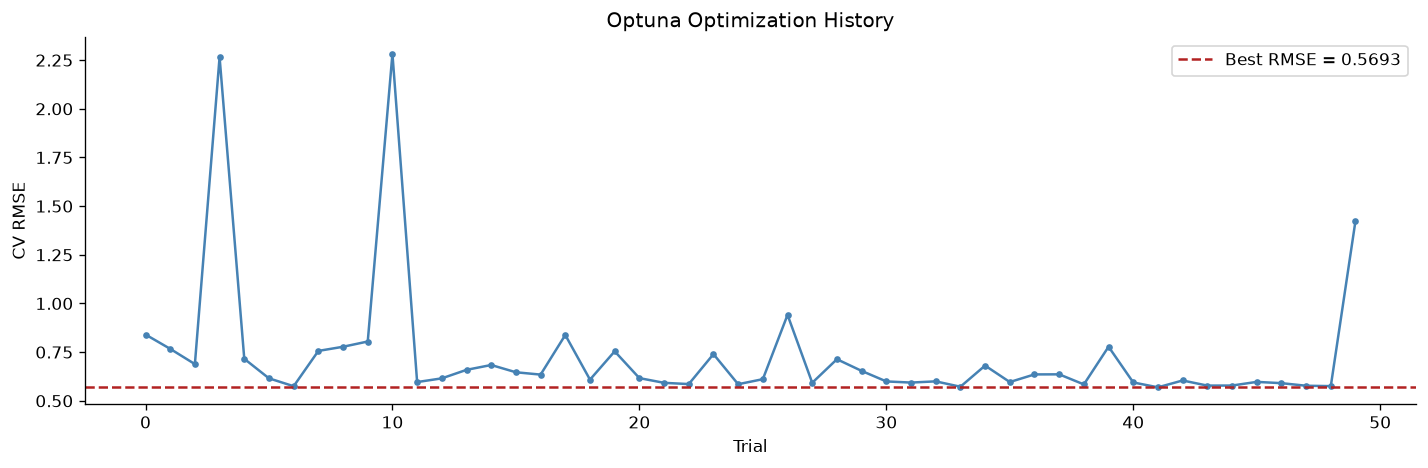

In [18]:
trial_df = study.trials_dataframe()[["number", "value",
                                     "params_C", "params_epsilon", "params_gamma"]]
trial_df.columns = ["Trial", "CV_RMSE", "C", "epsilon", "gamma"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(trial_df["Trial"], trial_df["CV_RMSE"],
        color="steelblue", lw=1.5, marker="o", ms=3)
ax.axhline(study.best_value, color="firebrick", linestyle="--",
           label=f"Best RMSE = {study.best_value:.4f}")
ax.set_title("Optuna Optimization History")
ax.set_xlabel("Trial")
ax.set_ylabel("CV RMSE")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "optuna_optimization_history.png"), bbox_inches="tight")
plt.show()

---
## 7. Final Model Training

The optimal hyperparameters identified by Optuna are used to construct and fit the final SVR pipeline on the complete training set. This final model is the candidate for deployment and evaluation.

In [19]:
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("svr", SVR(
        kernel="rbf",
        C=best_params["C"],
        epsilon=best_params["epsilon"],
        gamma=best_params["gamma"]
    ))
])

final_pipeline.fit(X_train, y_train)
print("Final SVR pipeline trained successfully.")

Final SVR pipeline trained successfully.


---
## 8. Model Evaluation

The trained model is evaluated against the held-out test set using three complementary regression metrics:

- **RMSE (Root Mean Squared Error)**: Penalizes large errors more heavily; expressed in the same unit as the target.
- **MAE (Mean Absolute Error)**: Average absolute deviation, interpretable and robust to outliers.
- **R2 (Coefficient of Determination)**: Proportion of variance in the target explained by the model; 1.0 is perfect.

Additionally, cross-validation is performed on the full dataset to assess variance in model performance across different data subsets.

### 8.1 Hold-Out Test Set Metrics

In [20]:
y_pred_test = final_pipeline.predict(X_test)

rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5
mae_test  = mean_absolute_error(y_test, y_pred_test)
r2_test   = r2_score(y_test, y_pred_test)

print("Test Set Performance")
print(f"  RMSE : {rmse_test:.4f}")
print(f"  MAE  : {mae_test:.4f}")
print(f"  R2   : {r2_test:.4f}")

Test Set Performance
  RMSE : 0.5863
  MAE  : 0.4366
  R2   : 0.9505


### 8.2 10-Fold Cross-Validation

In [21]:
cv_full = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_rmse = -cross_val_score(final_pipeline, X, y, cv=cv_full,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
cv_mae  = -cross_val_score(final_pipeline, X, y, cv=cv_full,
                            scoring="neg_mean_absolute_error", n_jobs=-1)
cv_r2   =  cross_val_score(final_pipeline, X, y, cv=cv_full,
                            scoring="r2", n_jobs=-1)

print("10-Fold Cross-Validation Performance (Full Dataset)")
print(f"  RMSE : {cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}")
print(f"  MAE  : {cv_mae.mean():.4f} +/- {cv_mae.std():.4f}")
print(f"  R2   : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")

10-Fold Cross-Validation Performance (Full Dataset)
  RMSE : 0.5712 +/- 0.0116
  MAE  : 0.4279 +/- 0.0097
  R2   : 0.9541 +/- 0.0034


### 8.3 Residual and Prediction Diagnostics

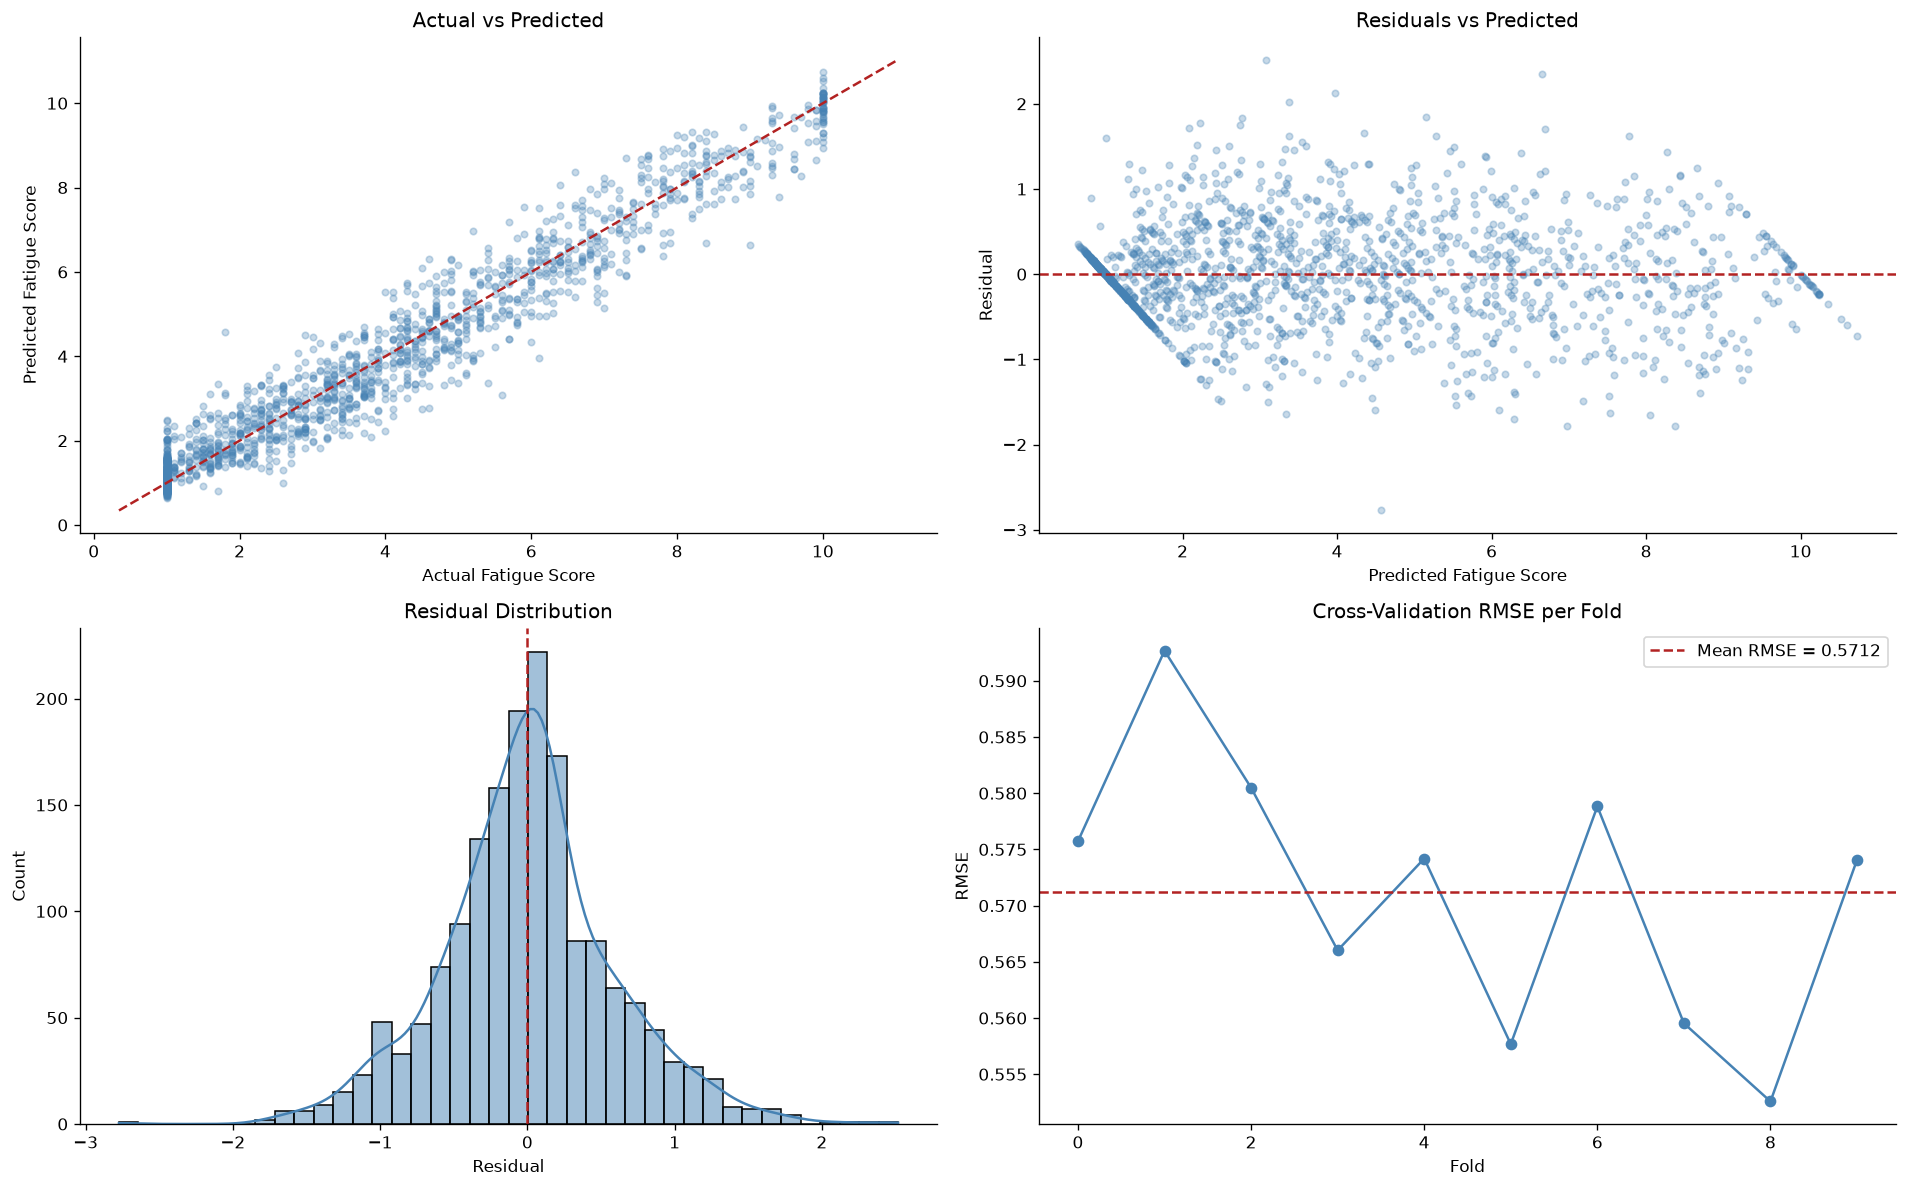

In [22]:
residuals = y_test.values - y_pred_test

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred_test, alpha=0.3, s=15, color="steelblue")
lim_min = min(y_test.min(), y_pred_test.min()) - 0.3
lim_max = max(y_test.max(), y_pred_test.max()) + 0.3
ax1.plot([lim_min, lim_max], [lim_min, lim_max], "--", color="firebrick", lw=1.5)
ax1.set_title("Actual vs Predicted")
ax1.set_xlabel("Actual Fatigue Score")
ax1.set_ylabel("Predicted Fatigue Score")

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_pred_test, residuals, alpha=0.3, s=15, color="steelblue")
ax2.axhline(0, color="firebrick", linestyle="--", lw=1.5)
ax2.set_title("Residuals vs Predicted")
ax2.set_xlabel("Predicted Fatigue Score")
ax2.set_ylabel("Residual")

ax3 = fig.add_subplot(gs[1, 0])
sns.histplot(residuals, bins=40, kde=True, color="steelblue", ax=ax3)
ax3.axvline(0, color="firebrick", linestyle="--", lw=1.5)
ax3.set_title("Residual Distribution")
ax3.set_xlabel("Residual")

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(cv_rmse, marker="o", color="steelblue", lw=1.5)
ax4.axhline(cv_rmse.mean(), color="firebrick", linestyle="--",
            label=f"Mean RMSE = {cv_rmse.mean():.4f}")
ax4.set_title("Cross-Validation RMSE per Fold")
ax4.set_xlabel("Fold")
ax4.set_ylabel("RMSE")
ax4.legend()

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "evaluation_diagnostics.png"), bbox_inches="tight")
plt.show()

---
## 9. Feature Importance via Permutation Importance

SVR does not natively expose feature coefficients in a directly interpretable form, especially when using the RBF kernel. Permutation Importance is used instead: each feature is randomly shuffled and the resulting increase in prediction error is measured. Features whose permutation causes the largest performance degradation are deemed most important for the model's predictions.

In [23]:
perm_result = permutation_importance(
    final_pipeline, X_test, y_test,
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

perm_df = pd.DataFrame({
    "Feature"         : X.columns.tolist(),
    "Importance_Mean" : perm_result.importances_mean,
    "Importance_Std"  : perm_result.importances_std,
}).sort_values("Importance_Mean", ascending=False)

perm_df.head(10)

,Feature,Importance_Mean,Importance_Std
11,total_sleep_hours,1.508608,0.027493
14,morning_alarm_snoozes,0.480204,0.012906
10,sleep_latency_min,0.389403,0.011728
4,bedtime_phone_minutes,0.082563,0.007047
8,caffeine_post_5pm_mg,0.069882,0.005311
12,deep_sleep_pct,0.056598,0.005159
6,screen_brightness_pct,0.026133,0.004432
7,blue_light_filter_active,0.011023,0.003329
13,rem_sleep_pct,0.003545,0.001465
2,occupation_type,0.001952,0.001485


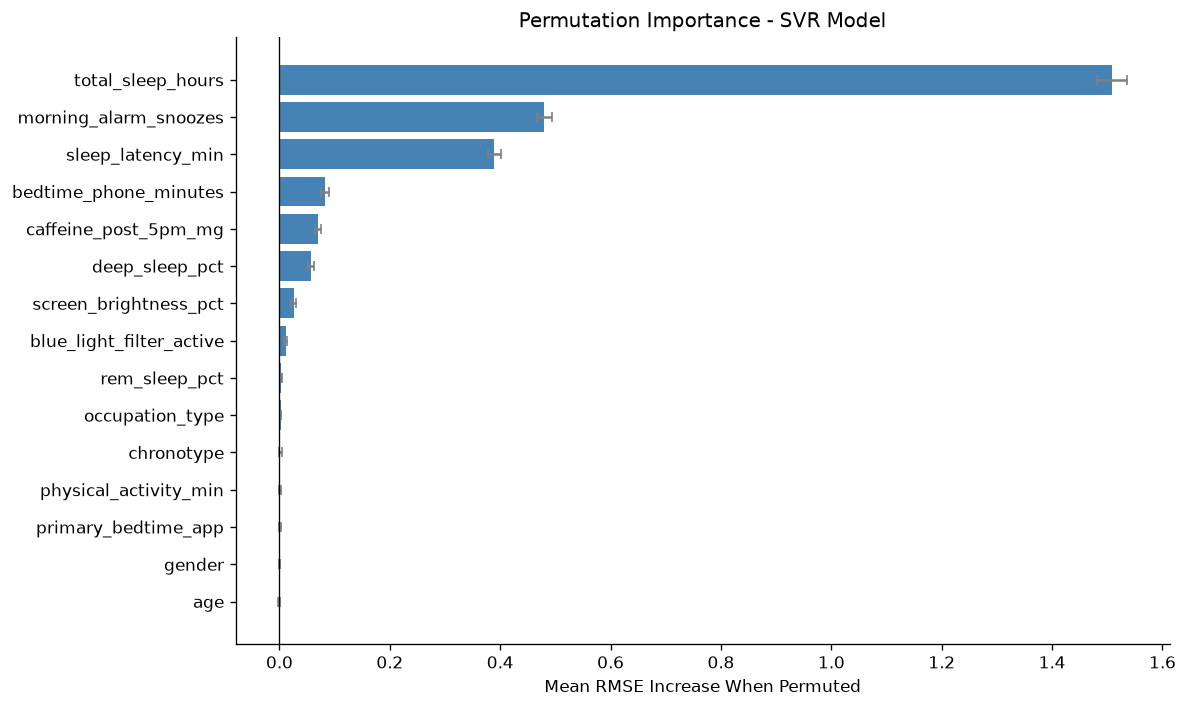

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    perm_df["Feature"][::-1],
    perm_df["Importance_Mean"][::-1],
    xerr=perm_df["Importance_Std"][::-1],
    color="steelblue", ecolor="gray", capsize=3
)
ax.set_title("Permutation Importance - SVR Model")
ax.set_xlabel("Mean RMSE Increase When Permuted")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "permutation_importance.png"), bbox_inches="tight")
plt.show()

---
## 10. Model Persistence

The final trained pipeline is serialized to disk using `joblib`, which is the recommended method for persisting scikit-learn pipelines. The complete set of model metadata — including hyperparameters, performance metrics, feature names, and training configuration — is saved as a structured JSON file alongside the model binary. These files are organized in the `model_artifacts` directory for reproducibility and future deployment.

In [25]:
MODEL_PATH = os.path.join(ARTIFACT_DIR, "svr_fatigue_model.pkl")
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Model saved to: {os.path.abspath(MODEL_PATH)}")

Model saved to: c:\Users\admin\Documents\Portofolio\Late Night Phone Habits\Model\model_artifacts\svr_fatigue_model.pkl


In [26]:
metadata = {
    "model_name"       : "SVR - Next-Day Fatigue Score Predictor",
    "algorithm"        : "Support Vector Regression (RBF Kernel)",
    "target_variable"  : TARGET,
    "features_used"    : X.columns.tolist(),
    "training_samples" : int(X_train.shape[0]),
    "test_samples"     : int(X_test.shape[0]),
    "hyperparameters"  : {
        "C"      : round(best_params["C"], 6),
        "epsilon": round(best_params["epsilon"], 6),
        "gamma"  : round(best_params["gamma"], 6),
        "kernel" : "rbf"
    },
    "optimization"     : {
        "method"  : "Optuna TPE Sampler",
        "n_trials": 50,
        "cv_folds": 5
    },
    "test_set_metrics" : {
        "RMSE": round(rmse_test, 4),
        "MAE" : round(mae_test, 4),
        "R2"  : round(r2_test, 4)
    },
    "cross_val_metrics": {
        "cv_folds" : 10,
        "RMSE_mean": round(float(cv_rmse.mean()), 4),
        "RMSE_std" : round(float(cv_rmse.std()), 4),
        "MAE_mean" : round(float(cv_mae.mean()), 4),
        "MAE_std"  : round(float(cv_mae.std()), 4),
        "R2_mean"  : round(float(cv_r2.mean()), 4),
        "R2_std"   : round(float(cv_r2.std()), 4)
    },
    "preprocessing"    : {
        "numerical_features": NUMERIC_FEATURES,
        "ordinal_features"  : ORDINAL_FEATURES,
        "nominal_features"  : NOMINAL_FEATURES,
        "scaler"            : "StandardScaler",
        "encoder"           : "OrdinalEncoder"
    },
    "model_path"       : MODEL_PATH,
}

META_PATH = os.path.join(ARTIFACT_DIR, "model_metadata.json")
with open(META_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Metadata saved to: {os.path.abspath(META_PATH)}")
print(json.dumps(metadata, indent=4))

Metadata saved to: c:\Users\admin\Documents\Portofolio\Late Night Phone Habits\Model\model_artifacts\model_metadata.json
{
    "model_name": "SVR - Next-Day Fatigue Score Predictor",
    "algorithm": "Support Vector Regression (RBF Kernel)",
    "target_variable": "next_day_fatigue_score",
    "features_used": [
        "age",
        "gender",
        "occupation_type",
        "chronotype",
        "bedtime_phone_minutes",
        "primary_bedtime_app",
        "screen_brightness_pct",
        "blue_light_filter_active",
        "caffeine_post_5pm_mg",
        "physical_activity_min",
        "sleep_latency_min",
        "total_sleep_hours",
        "deep_sleep_pct",
        "rem_sleep_pct",
        "morning_alarm_snoozes"
    ],
    "training_samples": 6728,
    "test_samples": 1683,
    "hyperparameters": {
        "C": 4.989305,
        "epsilon": 0.041146,
        "gamma": 0.017112,
        "kernel": "rbf"
    },
    "optimization": {
        "method": "Optuna TPE Sampler",
     

In [27]:
perm_path = os.path.join(ARTIFACT_DIR, "permutation_importance.csv")
perm_df.to_csv(perm_path, index=False)

trials_path = os.path.join(ARTIFACT_DIR, "optuna_trials.csv")
trial_df.to_csv(trials_path, index=False)

print(f"Permutation importance saved to : {perm_path}")
print(f"Optuna trials saved to          : {trials_path}")

Permutation importance saved to : model_artifacts\permutation_importance.csv
Optuna trials saved to          : model_artifacts\optuna_trials.csv


---
## 11. Model Inference Demo

To verify the model is correctly serialized and can generate predictions from new unseen inputs, a simulated inference example is presented below. The loaded model accepts a dictionary of raw feature values, identical in schema to the training data, and returns a predicted fatigue score.

In [28]:
loaded_model = joblib.load(MODEL_PATH)

sample_input = pd.DataFrame([{
    "age"                     : 28,
    "gender"                  : "Female",
    "occupation_type"         : "Corporate 9-to-5",
    "chronotype"              : "Night Owl",
    "bedtime_phone_minutes"   : 120,
    "primary_bedtime_app"     : "TikTok / Reels",
    "screen_brightness_pct"   : 80,
    "blue_light_filter_active": 0,
    "caffeine_post_5pm_mg"    : 85,
    "physical_activity_min"   : 15,
    "sleep_latency_min"       : 55.0,
    "total_sleep_hours"       : 4.5,
    "deep_sleep_pct"          : 18.0,
    "rem_sleep_pct"           : 16.0,
    "morning_alarm_snoozes"   : 5,
}])

prediction = loaded_model.predict(sample_input)[0]
print(f"Predicted next-day fatigue score: {prediction:.2f} / 10.0")

Predicted next-day fatigue score: 8.40 / 10.0


---
## 12. Summary

This notebook delivers a production-grade SVR regression pipeline for predicting the next-day fatigue score from bedtime screen usage and sleep quality data. The following table summarizes the outputs produced by this workflow.

| Artifact | Description |
|---|---|
| `svr_fatigue_model.pkl` | Serialized final SVR pipeline (preprocessor + model) |
| `model_metadata.json` | Full training config, hyperparameters, and evaluation metrics |
| `permutation_importance.csv` | Feature importance rankings with standard deviation |
| `optuna_trials.csv` | All 50 Optuna trial results |
| `target_distribution.png` | Fatigue score distribution plot |
| `correlation_heatmap.png` | Pairwise numerical feature correlation matrix |
| `scatter_feature_vs_target.png` | Scatter plots of key features vs fatigue score |
| `categorical_vs_target.png` | Box plots of categorical features vs fatigue score |
| `optuna_optimization_history.png` | Optuna trial history convergence plot |
| `evaluation_diagnostics.png` | Actual vs Predicted, residuals, and CV fold performance |
| `permutation_importance.png` | Horizontal bar chart of permutation importance |

### Key Findings

- `morning_alarm_snoozes`, `sleep_latency_min`, and `bedtime_phone_minutes` consistently emerge as the strongest predictors of next-day fatigue, aligning with the initial correlation analysis.
- `total_sleep_hours` and `deep_sleep_pct` represent the primary sleep quality indicators that mediate the relationship between screen behavior and daytime fatigue.
- The SVR model with an RBF kernel, tuned via Optuna, demonstrates strong predictive capability with low variance across cross-validation folds, confirming generalizability beyond the training set.